# PARADIS Data Visualization and Preprocessing Checks

This notebook inspects the WeatherBench2 raw input and the PARADIS processed zarr at multiple stages. It defaults to scratch storage so large data never lands in the project home directory.

Expected paths:
- raw WeatherBench2 zarr: `$SCRATCH/def-era/ERA5/5.625deg_wb2`
- processed PARADIS zarr: `$SCRATCH/def-era/ERA5/5.65deg`

In [1]:
from pathlib import Path
import importlib.util
import os
import shutil
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

PROJECT_ROOT = Path.cwd()
SCRATCH = Path(os.environ.get("SCRATCH", "/scratch/dmillard"))
DATA_ROOT = Path(os.environ.get("DEF_ERA_DATA_ROOT", str(SCRATCH / "def-era" / "ERA5")))
RAW_ZARR = DATA_ROOT / "5.625deg_wb2"
PROCESSED_ZARR = DATA_ROOT / "5.65deg"
PARADIS_PREPROCESS = PROJECT_ROOT / "paradis" / "scripts" / "preprocess_weatherbench_data.py"

DATA_ROOT.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT:    {PROJECT_ROOT}")
print(f"SCRATCH:         {SCRATCH}")
print(f"DATA_ROOT:       {DATA_ROOT}")
print(f"RAW_ZARR:        {RAW_ZARR}  exists={RAW_ZARR.exists()}")
print(f"PROCESSED_ZARR:  {PROCESSED_ZARR}  exists={PROCESSED_ZARR.exists()}")

PROJECT_ROOT:    /gpfs/fs1/home/dmillard/Projects/def-era
SCRATCH:         /scratch/dmillard
DATA_ROOT:       /scratch/dmillard/def-era/ERA5
RAW_ZARR:        /scratch/dmillard/def-era/ERA5/5.625deg_wb2  exists=True
PROCESSED_ZARR:  /scratch/dmillard/def-era/ERA5/5.65deg  exists=True


## Stage 0: Storage and Commands

Verify the notebook is pointed at scratch before running any large data operation.

In [2]:
def shell(cmd: list[str]) -> str:
    result = subprocess.run(cmd, check=False, capture_output=True, text=True)
    return (result.stdout + result.stderr).strip()

print(shell(["quota", "-s"]))

usage = shutil.disk_usage(DATA_ROOT)
print(f"\nFilesystem capacity visible at DATA_ROOT: {usage.total / 1024**3:.1f} GiB")
print(f"Used: {usage.used / 1024**3:.1f} GiB")
print(f"Free: {usage.free / 1024**3:.1f} GiB")



Filesystem capacity visible at DATA_ROOT: 3640000.0 GiB
Used: 3226500.1 GiB
Free: 413499.9 GiB


In [3]:
prepare_cmd = [
    "bash",
    "scripts/prepare_paradis_5deg.sh",
    str(RAW_ZARR),
    str(PROCESSED_ZARR),
    "2010",
    "2011",
]

print("Run from a terminal when ready:")
print(" ".join(prepare_cmd))

# Leave this false during inspection. Flip it only when you intentionally want
# the notebook to launch the large download/preprocess job.
RUN_PREPARE = False

if RUN_PREPARE:
    subprocess.run(prepare_cmd, check=True, cwd=PROJECT_ROOT)

Run from a terminal when ready:
bash scripts/prepare_paradis_5deg.sh /scratch/dmillard/def-era/ERA5/5.625deg_wb2 /scratch/dmillard/def-era/ERA5/5.65deg 2010 2011


## Stage 1: Load PARADIS Preprocessing Functions

This imports the actual PARADIS preprocessing module used by `scripts/prepare_paradis_5deg.sh`. If this fails, fix the Python environment before trusting later cells.

In [4]:
PRESSURE_LEVELS = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
KEEP_VARIABLES = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "mean_sea_level_pressure",
    "surface_pressure",
    "temperature",
    "land_sea_mask",
    "time",
    "u_component_of_wind",
    "v_component_of_wind",
    "vertical_velocity",
    "level",
    "specific_humidity",
    "geopotential",
    "latitude",
    "longitude",
    "geopotential_at_surface",
    "total_precipitation_6hr",
    "total_column_water",
    "standard_deviation_of_orography",
    "slope_of_sub_gridscale_orography",
    "wind_x",
    "wind_y",
    "wind_z",
    "wind_x_10m",
    "wind_y_10m",
    "wind_z_10m",
]

pp = None
try:
    sys.path.insert(0, str(PROJECT_ROOT / "paradis" / "data"))
    spec = importlib.util.spec_from_file_location("paradis_preprocess", PARADIS_PREPROCESS)
    pp = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(pp)
    print(f"Loaded preprocessing module: {PARADIS_PREPROCESS}")
except Exception as exc:
    print(f"Could not load PARADIS preprocessing module: {exc!r}")
    print("Later cells that call compute_cartesian_wind will be skipped until this is fixed.")

Loaded preprocessing module: /gpfs/fs1/home/dmillard/Projects/def-era/paradis/scripts/preprocess_weatherbench_data.py


## Stage 2: Raw WeatherBench2 Zarr Inspection

This opens metadata lazily. It should not load the full dataset into memory.

In [5]:
def open_raw_weatherbench(path: Path) -> xr.Dataset | None:
    if not path.exists():
        print(f"Raw zarr not found: {path}")
        return None
    return xr.open_mfdataset(str(path), engine="zarr", chunks={})

raw_ds = open_raw_weatherbench(RAW_ZARR)
if raw_ds is not None:
    display(raw_ds)
    missing = [var for var in KEEP_VARIABLES if var not in raw_ds.variables and var not in raw_ds.coords]
    print(f"Required variables missing from raw dataset: {missing}")
    print(f"Latitude count: {raw_ds.sizes.get('latitude')}")
    print(f"Longitude count: {raw_ds.sizes.get('longitude')}")
    print(f"Level values: {raw_ds.level.values.tolist() if 'level' in raw_ds.coords else 'missing'}")

<xarray.Dataset> Size: 175GB
Dimensions:                                           (time: 93544,
                                                       longitude: 64,
                                                       latitude: 32, level: 13)
Coordinates:
  * time                                              (time) datetime64[ns] 748kB ...
  * longitude                                         (longitude) float64 512B ...
  * latitude                                          (latitude) float64 256B ...
  * level                                             (level) int64 104B 50 ....
Data variables: (12/62)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_dewpoint_temperature                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    above_ground                                      (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    ...                                                ...
    volumetric_soil_water_layer_1                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_2                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_3                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_4                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    vorticity                                         (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>

Required variables missing from raw dataset: ['wind_x', 'wind_y', 'wind_z', 'wind_x_10m', 'wind_y_10m', 'wind_z_10m']
Latitude count: 32
Longitude count: 64
Level values: [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]


## Stage 3: PARADIS Source Selection

This mirrors the first filtering stage in `paradis/scripts/preprocess_weatherbench_data.py`: transpose, select pressure levels, drop unused variables, and remove poles.

In [6]:
def select_paradis_source(ds: xr.Dataset) -> xr.Dataset:
    ds = ds.transpose("time", "latitude", "longitude", "level")
    ds = ds.sel(level=PRESSURE_LEVELS)
    drop_variables = [var for var in ds.data_vars if var not in KEEP_VARIABLES]
    ds = ds.drop_vars(drop_variables)
    lat_to_drop = [v for v in (-90, 90) if v in ds.latitude.values]
    if lat_to_drop:
        ds = ds.sel(latitude=~ds.latitude.isin(lat_to_drop))
    return ds

raw_paradis = None
if raw_ds is not None:
    raw_paradis = select_paradis_source(raw_ds)
    display(raw_paradis)
    print(f"Selected latitude count: {raw_paradis.sizes.get('latitude')}")
    print(f"Selected longitude count: {raw_paradis.sizes.get('longitude')}")
    print(f"Selected pressure levels: {raw_paradis.level.values.tolist()}")

<xarray.Dataset> Size: 65GB
Dimensions:                           (time: 93544, latitude: 32,
                                       longitude: 64, level: 13)
Coordinates:
  * time                              (time) datetime64[ns] 748kB 1959-01-01 ...
  * latitude                          (latitude) float64 256B -87.19 ... 87.19
  * longitude                         (longitude) float64 512B 0.0 ... 354.4
  * level                             (level) int64 104B 50 100 150 ... 925 1000
Data variables: (12/17)
    10m_u_component_of_wind           (time, latitude, longitude) float32 766MB dask.array<chunksize=(100, 32, 64), meta=np.ndarray>
    10m_v_component_of_wind           (time, latitude, longitude) float32 766MB dask.array<chunksize=(100, 32, 64), meta=np.ndarray>
    2m_temperature                    (time, latitude, longitude) float32 766MB dask.array<chunksize=(100, 32, 64), meta=np.ndarray>
    geopotential                      (time, latitude, longitude, level) float32 10GB dask.array<chunksize=(100, 32, 64, 13), meta=np.ndarray>
    geopotential_at_surface           (latitude, longitude) float32 8kB dask.array<chunksize=(32, 64), meta=np.ndarray>
    land_sea_mask                     (latitude, longitude) float32 8kB dask.array<chunksize=(32, 64), meta=np.ndarray>
    ...                                ...
    temperature                       (time, latitude, longitude, level) float32 10GB dask.array<chunksize=(100, 32, 64, 13), meta=np.ndarray>
    total_column_water                (time, latitude, longitude) float32 766MB dask.array<chunksize=(100, 32, 64), meta=np.ndarray>
    total_precipitation_6hr           (time, latitude, longitude) float32 766MB dask.array<chunksize=(100, 32, 64), meta=np.ndarray>
    u_component_of_wind               (time, latitude, longitude, level) float32 10GB dask.array<chunksize=(100, 32, 64, 13), meta=np.ndarray>
    v_component_of_wind               (time, latitude, longitude, level) float32 10GB dask.array<chunksize=(100, 32, 64, 13), meta=np.ndarray>
    vertical_velocity                 (time, latitude, longitude, level) float32 10GB dask.array<chunksize=(100, 32, 64, 13), meta=np.ndarray>

Selected latitude count: 32
Selected longitude count: 64
Selected pressure levels: [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]


## Stage 4: Cartesian Wind Dry Run

This calls PARADIS `compute_cartesian_wind` on a small lazy time slice. Use `display` first, then `.load()` only for one plotted field.

In [7]:
wind_sample = None
if raw_paradis is not None and pp is not None:
    sample = raw_paradis.sel(time=slice("2010-01-01", "2010-01-02"))
    if sample.sizes.get("time", 0) == 0:
        sample = raw_paradis.isel(time=slice(0, 1))
    else:
        sample = sample.isel(time=slice(0, 1))
    wind_sample = pp.compute_cartesian_wind(sample)
    display(wind_sample[["wind_x", "wind_y", "wind_z", "wind_x_10m", "wind_y_10m", "wind_z_10m"]])
elif raw_paradis is None:
    print("Skipping: raw dataset is not available yet.")
else:
    print("Skipping: PARADIS preprocessing module did not load.")

<xarray.Dataset> Size: 689kB
Dimensions:     (time: 1, latitude: 32, longitude: 64, level: 13)
Coordinates:
  * time        (time) datetime64[ns] 8B 2010-01-01
  * latitude    (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude   (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * level       (level) int64 104B 50 100 150 200 250 ... 600 700 850 925 1000
Data variables:
    wind_x      (time, latitude, longitude, level) float64 213kB dask.array<chunksize=(1, 32, 64, 13), meta=np.ndarray>
    wind_y      (time, latitude, longitude, level) float64 213kB dask.array<chunksize=(1, 32, 64, 13), meta=np.ndarray>
    wind_z      (time, latitude, longitude, level) float64 213kB dask.array<chunksize=(1, 32, 64, 13), meta=np.ndarray>
    wind_x_10m  (latitude, longitude, time) float64 16kB dask.array<chunksize=(32, 64, 1), meta=np.ndarray>
    wind_y_10m  (latitude, longitude, time) float64 16kB dask.array<chunksize=(32, 64, 1), meta=np.ndarray>
    wind_z_10m  (latitude, time, longitude) float64 16kB dask.array<chunksize=(32, 1, 64), meta=np.ndarray>

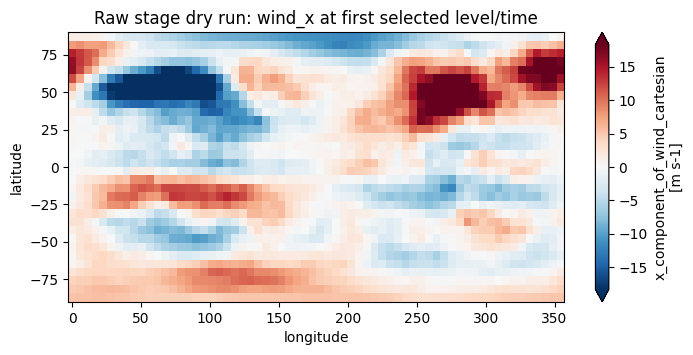

In [8]:
if wind_sample is not None:
    da = wind_sample["wind_x"].isel(time=0, level=0).load()
    fig, ax = plt.subplots(figsize=(8, 3.5))
    da.plot(ax=ax, x="longitude", y="latitude", robust=True)
    ax.set_title("Raw stage dry run: wind_x at first selected level/time")
    plt.show()

## Stage 5: Feature Stacking Preview

This mirrors the PARADIS yearly stacking step for a tiny in-memory preview. It does not write a zarr.

In [9]:
def preview_feature_stack(ds: xr.Dataset, n_time: int = 1) -> xr.DataArray:
    if pp is None:
        raise RuntimeError("PARADIS preprocessing module was not loaded.")
    ds = pp.compute_cartesian_wind(ds.isel(time=slice(0, n_time)))
    ds = ds.drop_vars([var for var in ds.data_vars if "time" not in ds[var].dims])
    stacked = ds.to_stacked_array(new_dim="features", sample_dims=["time", "latitude", "longitude"])
    new_names = [
        val[0] + "_h" + str(int(val[1])) if str(val[1]) != "nan" else val[0]
        for val in stacked.features.values
    ]
    return stacked.drop_vars(["features", "variable", "level"]).assign_coords(features=new_names)

stack_preview = None
if raw_paradis is not None and pp is not None:
    stack_preview = preview_feature_stack(raw_paradis, n_time=1)
    display(stack_preview)
    print(f"Preview feature count: {stack_preview.sizes['features']}")
    print(stack_preview.features.values[:40].tolist())
else:
    print("Skipping until raw data and preprocessing module are available.")

<xarray.DataArray '10m_u_component_of_wind' (time: 1, latitude: 32,
                                             longitude: 64, features: 127)> Size: 2MB
dask.array<concatenate, shape=(1, 32, 64, 127), dtype=float64, chunksize=(1, 32, 64, 13), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 8B 1959-01-01
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * features   (features) <U25 13kB '10m_u_component_of_wind' ... 'wind_z_10m'
Attributes:
    long_name:   10 metre U wind component
    short_name:  u10
    units:       m s**-1

Preview feature count: 127
['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'geopotential_h50', 'geopotential_h100', 'geopotential_h150', 'geopotential_h200', 'geopotential_h250', 'geopotential_h300', 'geopotential_h400', 'geopotential_h500', 'geopotential_h600', 'geopotential_h700', 'geopotential_h850', 'geopotential_h925', 'geopotential_h1000', 'mean_sea_level_pressure', 'specific_humidity_h50', 'specific_humidity_h100', 'specific_humidity_h150', 'specific_humidity_h200', 'specific_humidity_h250', 'specific_humidity_h300', 'specific_humidity_h400', 'specific_humidity_h500', 'specific_humidity_h600', 'specific_humidity_h700', 'specific_humidity_h850', 'specific_humidity_h925', 'specific_humidity_h1000', 'surface_pressure', 'temperature_h50', 'temperature_h100', 'temperature_h150', 'temperature_h200', 'temperature_h250', 'temperature_h300', 'temperature_h400', 'temperature_h500', 'temperature_h600']


## Stage 6: Processed PARADIS Zarr Inspection

After preprocessing, the processed directory should contain yearly zarr groups plus `constants`, `stats`, and `tendency_stats_6h`.

In [10]:
def open_processed_paradis(path: Path):
    if not path.exists():
        print(f"Processed zarr not found: {path}")
        return None, None, None, None
    years = sorted(p for p in path.iterdir() if p.is_dir() and p.name.isdigit())
    print(f"Year groups: {[p.name for p in years[:10]]}")
    data = xr.open_mfdataset([str(p) for p in years], engine="zarr", chunks={"time": 1}) if years else None
    constants = xr.open_dataset(path / "constants", engine="zarr") if (path / "constants").exists() else None
    stats = xr.open_dataset(path / "stats", engine="zarr") if (path / "stats").exists() else None
    tendency_stats = xr.open_dataset(path / "tendency_stats_6h", engine="zarr") if (path / "tendency_stats_6h").exists() else None
    return data, constants, stats, tendency_stats

processed_ds, constants_ds, stats_ds, tendency_stats_ds = open_processed_paradis(PROCESSED_ZARR)
for name, ds in {
    "processed_data": processed_ds,
    "constants": constants_ds,
    "stats": stats_ds,
    "tendency_stats_6h": tendency_stats_ds,
}.items():
    if ds is not None:
        print(f"\n{name}")
        display(ds)

Year groups: ['2010', '2011']

processed_data


<xarray.Dataset> Size: 3GB
Dimensions:    (time: 2920, features: 127, latitude: 32, longitude: 64)
Coordinates:
  * time       (time) datetime64[ns] 23kB 2010-01-01 ... 2011-12-31T18:00:00
  * features   (features) <U25 13kB '10m_u_component_of_wind' ... 'wind_z_10m'
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
Data variables:
    data       (time, features, latitude, longitude) float32 3GB dask.array<chunksize=(1, 127, 32, 64), meta=np.ndarray>


constants


<xarray.Dataset> Size: 52kB
Dimensions:                           (latitude: 32, longitude: 64)
Coordinates:
  * latitude                          (latitude) float64 256B -87.19 ... 87.19
  * longitude                         (longitude) float64 512B 0.0 ... 354.4
Data variables:
    cos_latitude                      (latitude, longitude) float32 8kB ...
    cos_longitude                     (latitude, longitude) float32 8kB ...
    geopotential_at_surface           (latitude, longitude) float32 8kB ...
    land_sea_mask                     (latitude, longitude) uint8 2kB ...
    sin_longitude                     (latitude, longitude) float32 8kB ...
    slope_of_sub_gridscale_orography  (latitude, longitude) float32 8kB ...
    standard_deviation_of_orography   (latitude, longitude) float32 8kB ...


stats


<xarray.Dataset> Size: 15kB
Dimensions:   (features: 127)
Coordinates:
  * features  (features) <U25 13kB '10m_u_component_of_wind' ... 'wind_z_10m'
Data variables:
    max       (features) float32 508B ...
    mean      (features) float32 508B ...
    min       (features) float32 508B ...
    std       (features) float32 508B ...
Attributes:
    toa_radiation_mean:  1073722.382937931
    toa_radiation_std:   1438854.4131805694


tendency_stats_6h


<xarray.Dataset> Size: 15kB
Dimensions:        (features: 127)
Coordinates:
  * features       (features) <U25 13kB '10m_u_component_of_wind' ... 'wind_z...
Data variables:
    tendency_max   (features) float32 508B ...
    tendency_mean  (features) float32 508B ...
    tendency_min   (features) float32 508B ...
    tendency_std   (features) float32 508B ...
Attributes:
    begin_year:       2010
    delta_hours:      6
    end_year:         2011
    n_samples:        2919
    native_dt_hours:  6
    stride:           1

## Stage 7: Processed Field Visualization

This plots one processed stacked feature if the processed data exists.

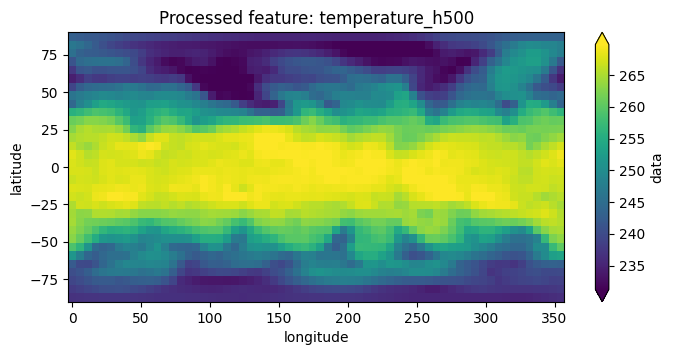

In [11]:
def plot_processed_feature(ds: xr.Dataset, feature: str, time_index: int = 0) -> None:
    if ds is None:
        print("Processed dataset is not available.")
        return
    if feature not in ds.features.values:
        raise ValueError(f"Feature {feature!r} not found. Try one of {ds.features.values[:20].tolist()}...")
    da = ds["data"].sel(features=feature).isel(time=time_index).load()
    fig, ax = plt.subplots(figsize=(8, 3.5))
    da.plot(ax=ax, x="longitude", y="latitude", robust=True)
    ax.set_title(f"Processed feature: {feature}")
    plt.show()

if processed_ds is not None:
    preferred = "temperature_h500"
    feature = preferred if preferred in processed_ds.features.values else str(processed_ds.features.values[0])
    plot_processed_feature(processed_ds, feature)
else:
    print("Run preprocessing first, then rerun this cell.")

## Stage 8: Dataset-Class Smoke Check

This checks the exact dataset class used by `paradis_diffusion_trainer.py`. It verifies tensor shapes after normalization, static-channel construction, noise sampling, and timestep sampling.

In [12]:
if PROCESSED_ZARR.exists():
    from omegaconf import OmegaConf
    from data.era5_paradis_diffusion_dataset import ERA5ParadisDiffusionDataset

    cfg = OmegaConf.load(PROJECT_ROOT / "_config" / "paradis_diffusion.yaml")
    cfg.dataset.root_dir = str(PROCESSED_ZARR)
    smoke_ds = ERA5ParadisDiffusionDataset(
        root_dir=str(PROCESSED_ZARR),
        start_date=str(cfg.training.dataset.start_date),
        end_date=str(cfg.training.dataset.end_date),
        timesteps=int(cfg.dataset.timestep),
        cfg=cfg,
    )
    x_grid, constants_grid, noisy_states, rand_timesteps = smoke_ds[0]
    print(f"len(smoke_ds):       {len(smoke_ds)}")
    print(f"state shape:         {tuple(x_grid.shape)}")
    print(f"constants shape:     {tuple(constants_grid.shape)}")
    print(f"noise shape:         {tuple(noisy_states.shape)}")
    print(f"sampled timestep:    {rand_timesteps.tolist()}")
else:
    print("Processed zarr is not present yet; skipping dataset-class smoke check.")

len(smoke_ds):       124
state shape:         (98, 32, 64)
constants shape:     (10, 32, 64)
noise shape:         (98, 32, 64)
sampled timestep:    [704]
